## DATA 620 Project 2

### Introduction

We will be analyzing the Digg dataset from https://networkrepository.com/digg.php. Digg is a news aggregator site in a similar vein as Reddit. In a lot of ways, it's effectively a social network. This can be seen in the dataset's two distinct **type of nodes: users and stories**.

*  Users are connected to each other through stories that they like.
*  Stories do not have an innate meaning in this graph without their connections to users.

In the original data, users actually can be connected to each other through friendships as well, but we will ignore those for our purpose. Instead, we will analyze `digg_reduced.edges` which removes the connections between users and greatly speeds up loading times.

**Note: During the process of working on this project, it was discovered that the dataset was very slow to operate on. Instead of redoing existing work, the graph operated on was reduced via edge sampling. There will be some discourse regarding the risks of this process.**

In [ ]:
# Imports
import pandas as pd
import networkx as nx
import networkx.algorithms.bipartite as bipartite
import random
import matplotlib.pyplot as plt
import seaborn as sns

### EDA and Cleanup of Initial Files



Edge and type files are both based on each row containing some sort of connection.

In [14]:
# Original edges file

# Load digg.edges
df_edges = pd.read_csv('digg.edges', sep=',', header=None, names=['source', 'target', 'timestamp'])

# Load digg.types
df_types = pd.read_csv('digg.types', sep=',', header=None, names=['node', 'type'])

display(df_edges.head())
display(df_types.head())

print(f'Total number of edges: {len(df_edges)}')
print(f'Total number of nodes: {len(df_types)}')

,source,target,timestamp
0,1,2,1214799565
1,1,3,1230047012
2,1,4,1194104160
3,1,5,1199180573
4,1,6,1196465462


,node,type
0,1,1
1,2,1
2,3,1
3,4,1
4,5,1


Total number of edges: 4749850
Total number of nodes: 283183


Our "original" graph checks for node type. Type is 1 for user and 2 for story. We only want (directed) edges that connected 1 -> 2 or 2 -> 1.

In [2]:
# Original graph creation

G = nx.DiGraph()

# Add edges from df_edges
for index, row in df_edges.iterrows():
    G.add_edge(row['source'], row['target'])

# Convert df_types to a dictionary for node attributes
node_types_dict = df_types.set_index('node')['type'].to_dict()

# Assign node types as attributes to the graph nodes
nx.set_node_attributes(G, node_types_dict, 'type')

inter_type_edges = []

# Loop through every edge in the graph G
for u, v in G.edges():
    # Retrieve the 'type' attribute for node u
    u_type = G.nodes[u]['type']
    # Retrieve the 'type' attribute for node v
    v_type = G.nodes[v]['type']

    # If the type of node u is not equal to the type of node v, append the edge to the list
    if u_type != v_type:
        inter_type_edges.append((u, v))

# Print the total number of inter-type edges found
print(f'Total number of inter-type edges: {len(inter_type_edges)}')

Total number of inter-type edges: 3010898


In [3]:
# Create a DataFrame from the inter_type_edges list
df_inter_type_edges = pd.DataFrame(inter_type_edges, columns=['source', 'target'])

# Save the DataFrame to a CSV file without the index
df_inter_type_edges.to_csv('digg_reduced.edges', index=False, header=False)

Successfully saved 3010898 inter-type edges to digg_reduced.edges


We reduce our initial 4749850 edges to 3010898. The main reduction is simplifying what an edge means. Edges are only about liked stories and not user friendships going forward.

In [19]:
# Load saved reduced edges file
df_reduced_edges = pd.read_csv('digg_reduced.edges', sep=',', header=None, names=['source', 'target'])
display(df_reduced_edges.head())
df_reduced_edges.shape

,source,target
0,1,279631
1,1,279646
2,1,279662
3,1,279841
4,1,280026


(3010898, 2)

While we removed the same type links, we do not know much about the remaining links. The Network Repository claimed that the edges we kept are only about liked stories. This implies that there are probably no edges that lead from story to user.

,node,type
0,1,1
1,2,1
2,3,1
3,4,1
4,5,1


Total users: 279630
Total stories: 3553


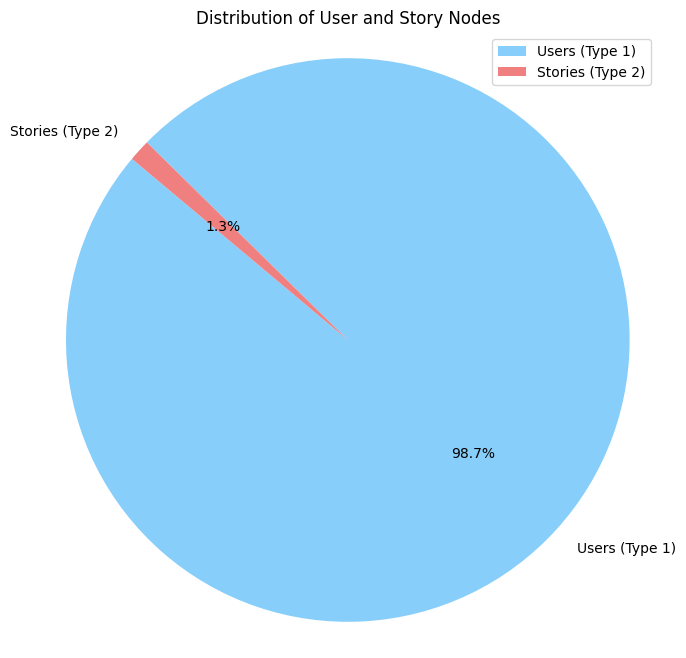

In [22]:
df_node_types = pd.read_csv('digg.types', sep=',', header=None, names=['node', 'type'])

display(df_node_types.head())

user_count = len(df_node_types[df_node_types['type'] == 1])
story_count = len(df_node_types[df_node_types['type'] == 2])

print(f'Total users: {user_count}')
print(f'Total stories: {story_count}')

labels = ['Users (Type 1)', 'Stories (Type 2)']
sizes = [user_count, story_count]
colors = ['lightskyblue', 'lightcoral']

plt.close()
plt.figure(figsize=(8, 8))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140)
plt.title('Distribution of User and Story Nodes')
plt.axis('equal')
plt.legend(labels, loc='best')
plt.show()

For our nodes, we have a tremendous amount of users with 279630 compared to only 3553 stories. This difference is likely because the site is more of a news posting site than a strict social network. Stories are content posts that all users, even those that never post any themselves, can engage with. This is unlike the Southern Davis Clubs where women were attending in person and more likely to interact and have connections with each other more directly.

In [98]:
# Make graph from dataframe
G_reduced = nx.Graph()
G_reduced = nx.from_pandas_edgelist(df_reduced_edges, source='source', target='target', create_using=G_reduced)

node_types_dict = df_node_types.set_index('node')['type'].to_dict()
nx.set_node_attributes(G_reduced, node_types_dict, 'type')

print(f'Number of nodes: {G_reduced.number_of_nodes()}')
print(f'Number of edges: {G_reduced.number_of_edges()}')

Number of nodes: 142962
Number of edges: 3010898


A user liking a story implies a directed graph may be suitable, but we can see that it's not necessary to delineate because...

In [96]:
df_merged_sources = pd.merge(df_reduced_edges, df_node_types, left_on='source', right_on='node', how='left')
df_merged_sources = df_merged_sources.rename(columns={'type': 'source_type'})
display(df_merged_sources.head())
df_merged_sources.shape

sources_type_2 = df_merged_sources[df_merged_sources['source_type'] == 2]
count_sources_type_2 = len(sources_type_2)

if count_sources_type_2 > 0:
    print(f'There are {count_sources_type_2} instances where the source node is of type 2.')
else:
    print('There are no instances where the source node is of type 2.')

,source,target,node,source_type
0,1,279631,1,1
1,1,279646,1,1
2,1,279662,1,1
3,1,279841,1,1
4,1,280026,1,1


There are no instances where the source node is of type 2.


We have no edges that lead from stories (type 2) to users (type 1). This means all edges strictly show users liking stories.

### Initial Centrality Measures

In [31]:
degree_centrality = nx.degree_centrality(G_reduced)
user_centrality = {}
story_centrality = {}

for node, centrality in degree_centrality.items():
    node_type = G_reduced.nodes[node]['type']
    if node_type == 1:
        user_centrality[node] = centrality
    elif node_type == 2:
        story_centrality[node] = centrality

user_centrality_series = pd.Series(user_centrality)
story_centrality_series = pd.Series(story_centrality)

print("Descriptive statistics for User Node Centrality:")
display(user_centrality_series.describe())

print("\nDescriptive statistics for Story Node Centrality:")
display(story_centrality_series.describe())



Descriptive statistics for User Node Centrality:


,0
count,139409.000000
mean,0.000151
std,0.000543
min,0.000007
25%,0.000007
50%,0.000028
75%,0.000098
max,0.023888



Descriptive statistics for Story Node Centrality:


,0
count,3553.000000
mean,0.005928
std,0.006900
min,0.000853
25%,0.002588
50%,0.003686
75%,0.006016
max,0.168347


User nodes generally have much lower average degree centrality compared to story nodes. The maximum centrality for user nodes is also significantly lower than for story nodes. This means that stories have far more connections than users which makes sense considering the disparity in totals of each.

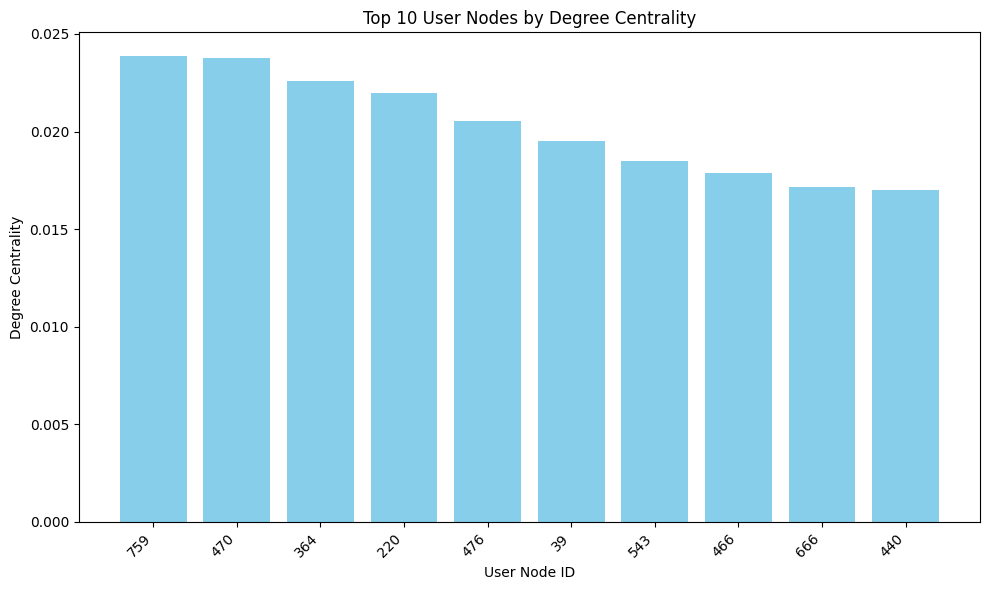

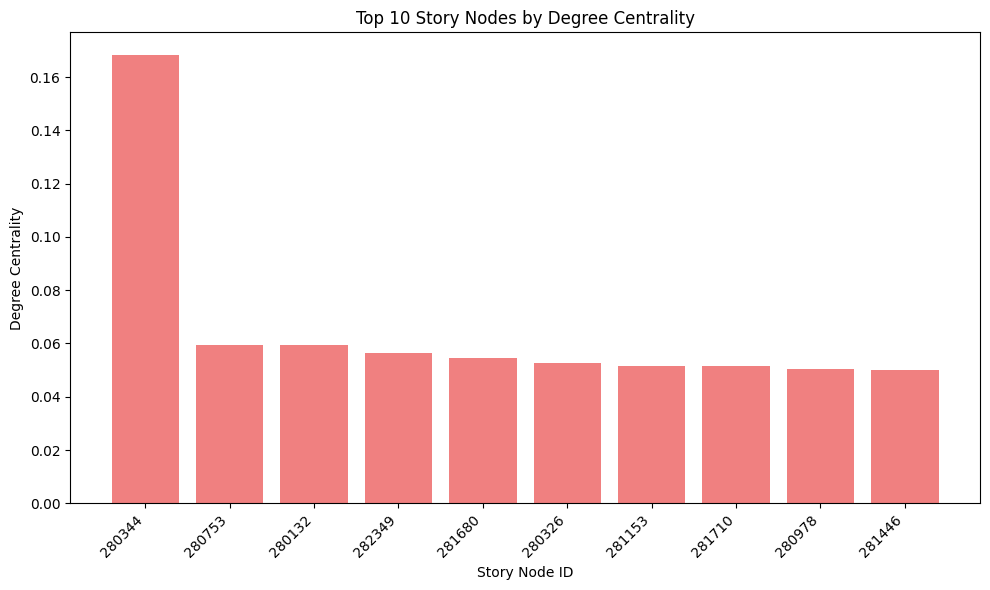

In [37]:
# Define N for top nodes (to make it easier to adjust as needed)
N = 10

# Get top N user centralities
top_n_users = user_centrality_series.nlargest(N)

# Get top N story centralities
top_n_stories = story_centrality_series.nlargest(N)

# Plotting Top N User Centralities
plt.figure(figsize=(10, 6))
plt.bar(top_n_users.index.astype(str), top_n_users.values, color='skyblue')
plt.xlabel('User Node ID')
plt.ylabel('Degree Centrality')
plt.title(f'Top {N} User Nodes by Degree Centrality')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Plotting Top N Story Centralities
plt.figure(figsize=(10, 6))
plt.bar(top_n_stories.index.astype(str), top_n_stories.values, color='lightcoral')
plt.xlabel('Story Node ID')
plt.ylabel('Degree Centrality')
plt.title(f'Top {N} Story Nodes by Degree Centrality')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Without being able to identify who or what each node is, the comparisons would not mean much if both bar plots looked like the top 10 users. However, `280344` looks really unusual for story nodes. Let's visualize how odd it actually is.

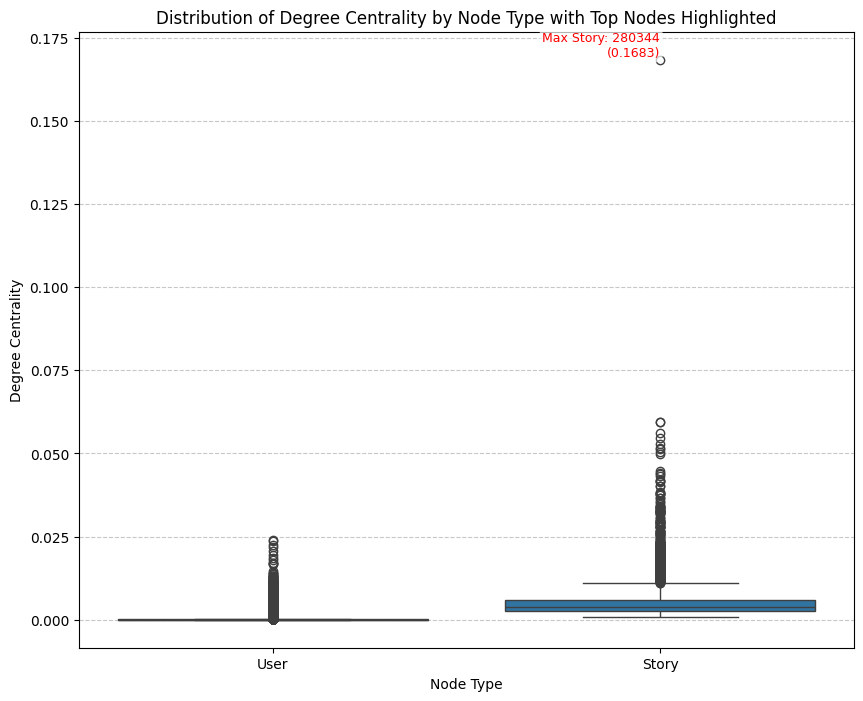

In [39]:
# Identify the node with the highest degree centrality for stories
top_story_node_id = story_centrality_series.idxmax()
top_story_centrality = story_centrality_series.max()

# Combine user and story centrality series into a single DataFrame
all_centrality = pd.concat([
    user_centrality_series.rename('Centrality').to_frame().assign(Type='User'),
    story_centrality_series.rename('Centrality').to_frame().assign(Type='Story')
])

plt.figure(figsize=(10, 8))
sns.boxplot(x='Type', y='Centrality', data=all_centrality)
plt.title('Distribution of Degree Centrality by Node Type with Top Nodes Highlighted')
plt.xlabel('Node Type')
plt.ylabel('Degree Centrality')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Annotate the plot with the top story node
plt.text(
    1, # 'Story' category is at x=1
    top_story_centrality,
    f'Max Story: {top_story_node_id}\n({top_story_centrality:.4f})',
    horizontalalignment='right',
    verticalalignment='bottom',
    fontsize=9,
    color='red',
    bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.2')
)

plt.show()

This plot shows how much of an outlier `280344` actually is. The rest of the plots are heavily compressed as a result. This story has an extremely high amount of user likes for a story.

Even besides that main outlier, we can see that stories typically have a low degree centrality with select stories rising far above the rest. Engagement metrics can show us a content's virality. The outliers often have something special about them that position them above the average post.  

As this "reduced" graph is too large to visualize without extremely long computing times/timing out. We will proceed with doing textbook reducing methods.

### Reducing a Large Graph

One method of reducing graphs is by creating "islands". There are a few ways to go about it. Since we have a special `280344` node with an extremely high centrality, reducing the graph based on removing its connection is a good option.

In [62]:
# sorted_degrees = sorted(G_reduced.degree(), key=lambda x: x[1], reverse=True)

# # Print top 5 nodes by degree
# print(sorted_degrees[:5])

# nodes_keep = [node for node, degree in G_reduced.degree() if degree > 1]
# G_island = G_reduced.subgraph(nodes_keep)

# print('\nDegrees in the new subgraph:')
# pd.DataFrame(list(dict(G_island.degree()).items()), columns=['Node', 'Degree']).head()

In [63]:
# # Get the degrees of all nodes in G_reduced
# degrees = [d for n, d in G_reduced.degree()]

# # Identify the maximum degree to omit
# # Using sorted_degrees from previous execution results, the highest degree is 24067 (from node 280344)
# max_degree_to_omit = sorted_degrees[0][1] if sorted_degrees else max(degrees)

# # Filter out the highest degree for better visualization of the rest
# degrees_filtered = [d for d in degrees if d < max_degree_to_omit]

# plt.figure(figsize=(12, 6))
# sns.histplot(degrees_filtered, bins=50, kde=True)
# plt.title('Distribution of Node Degrees in G_reduced (Excluding Highest Degree)')
# plt.xlabel('Node Degree')
# plt.ylabel('Number of Nodes')
# plt.yscale('log') # Use a log scale for the y-axis to better visualize the spread, given the potential for many low-degree nodes
# plt.grid(axis='y', linestyle='--', alpha=0.7)
# plt.show()

In [79]:
# Target a node with high degree
node_to_reduce = 280344
G_island = G_reduced.copy()

# Remove all edges connected to that node
edges_to_remove = list(G_island.edges(node_to_reduce))
G_island.remove_edges_from(edges_to_remove)

# This line affects how many components should G_island be broken into
while nx.number_connected_components(G_island) < 3000:
    edge_centrality = nx.edge_betweenness_centrality(G_island)
    edge_to_remove = max(edge_centrality, key=edge_centrality.get)
    G_island.remove_edge(*edge_to_remove)

print(f'Number of nodes in G_island: {G_island.number_of_nodes()}')
print(f'Number of edges in G_island: {G_island.number_of_edges()}')
print(f'Number of connected components in G_island: {nx.number_connected_components(G_island)}')


Number of nodes in G_island: 142962
Number of edges in G_island: 2986831
Number of connected components in G_island: 2389


Number of nodes in G_island: 142962

Number of edges in G_island: 2986831

Number of connected components in G_island: 2389

Very little change occurred. Each iteration should remove an edge with the highest remaining betweenness centrality. Scaling the number above 3000 slowed the code to a halt.


In [80]:
# Saving graph because Colab is unable to do further reduction without wasting hours
nx.write_gexf(G_island, 'G_island.gexf')
print("G_island saved to 'G_island.gexf'")

G_island saved to 'G_island.gexf'


### Dataset Too Large For Processing

Unfortunately, many hours/days were spent trying to operate on this graph as the chosen dataset may have been too ambitious. Aside from the above, there was also a version of the reduction code using strongly connected components. That version resulted in a larger reduced graph than the kept version.

**The reduction results did not change for any values between 100 and 3000, greatly implying that there were not many low density candidates for removal. Furthermore, attempting to use a high value increased the run time by significant amounts.**

We will keep the code that created `G_island`. However, we will instead analyze a graph that is further reduced using random sampling.

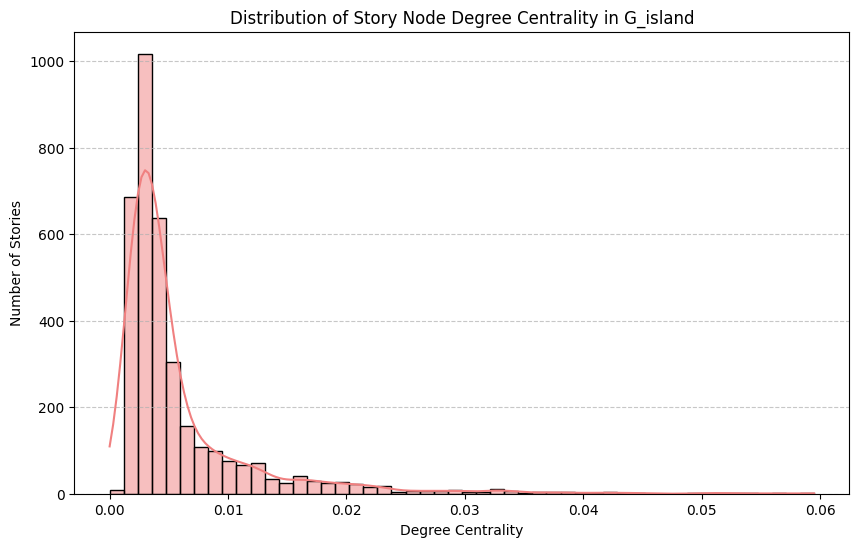

In [156]:
degree_centrality_G_island = nx.degree_centrality(G_island)

story_centrality_G_island = {}

for node, centrality in degree_centrality_G_island.items():
    node_type = G_island.nodes[node]['type']
    if node_type == 2:
        story_centrality_G_island[node] = centrality

story_centrality_series_G_island = pd.Series(story_centrality_G_island)

plt.figure(figsize=(10, 6))
sns.histplot(story_centrality_series_G_island, bins=50, kde=True, color='lightcoral')
plt.title('Distribution of Story Node Degree Centrality in G_island')
plt.xlabel('Degree Centrality')
plt.ylabel('Number of Stories')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

The degree centrality spread of G_island was right-skewed. We will use this as reference.

In [157]:
df_G_island_edges = pd.DataFrame(G_island.edges(), columns=['source', 'target'])

# Randomly sample 1% of the edges
df_G_island_sampled_edges = df_G_island_edges.sample(frac=0.01, random_state=42)

# Create a new directed graph from the sampled edges
G_edge_sampled = nx.from_pandas_edgelist(df_G_island_sampled_edges, source='source', target='target', create_using=nx.DiGraph())

# Assign node type attributes to G_edge_sampled using the existing node_types_dict
nx.set_node_attributes(G_edge_sampled, node_types_dict, 'type')

# Print the requested statistics
print(f'Original number of edges in G_island: {G_island.number_of_edges()}')
print(f'Sampled number of edges in G_edge_sampled: {G_edge_sampled.number_of_edges()}')
print(f'Number of nodes in G_edge_sampled: {G_edge_sampled.number_of_nodes()}')

Original number of edges in G_island: 2986831
Sampled number of edges in G_edge_sampled: 29868
Number of nodes in G_edge_sampled: 20430


Randomly sample 1% of edges. The preference for edge sampling is to preserve existing relations. There are much fewer edges compared to nodes now, but that is the give and take for this process. Focusing on the nodes could lead to key connections being lost or misrepresented.

Descriptive statistics for Story Node Centrality in G_edge_sampled:


,0
count,3482.000000
mean,0.000420
std,0.000464
min,0.000049
25%,0.000147
50%,0.000294
75%,0.000490
max,0.004797


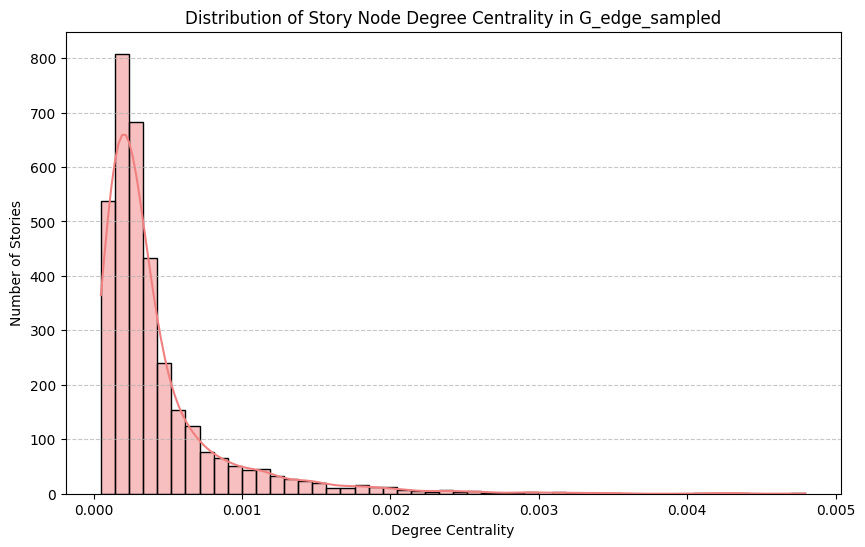

In [160]:
degree_centrality_G_edge_sampled = nx.degree_centrality(G_edge_sampled)

story_centrality_G_edge_sampled = {}

for node, centrality in degree_centrality_G_edge_sampled.items():
    # Ensure the node exists in node_types_dict before accessing its type
    if node in node_types_dict:
        node_type = node_types_dict[node]
        if node_type == 2:
            story_centrality_G_edge_sampled[node] = centrality

story_centrality_series_G_edge_sampled = pd.Series(story_centrality_G_edge_sampled)

print("Descriptive statistics for Story Node Centrality in G_edge_sampled:")
display(story_centrality_series_G_edge_sampled.describe())

plt.figure(figsize=(10, 6))
sns.histplot(story_centrality_series_G_edge_sampled, bins=50, kde=True, color='lightcoral')
plt.title('Distribution of Story Node Degree Centrality in G_edge_sampled')
plt.xlabel('Degree Centrality')
plt.ylabel('Number of Stories')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Note that this distribution for degree centrality for stories is similar to the presampling data.

### Bipartite Graph Analysis

We can projected users onto stories to discover what users like the same stories. Likewise, projecting stories onto users tells us about stories that are liked by a specific user. Let's see what we can infer about our two groups.

In [163]:
user_nodes_G_edge_sampled = [n for n, data in G_edge_sampled.nodes(data=True) if data.get('type') == 1]

print(f'Number of user nodes identified in G_edge_sampled: {len(user_nodes_G_edge_sampled)}')

G_user_projection = bipartite.projected_graph(G_edge_sampled, user_nodes_G_edge_sampled)

print(f'Number of nodes in G_user_projection: {G_user_projection.number_of_nodes()}')
print(f'Number of edges in G_user_projection: {G_user_projection.number_of_edges()}')

Number of user nodes identified in G_edge_sampled: 16948
Number of nodes in G_user_projection: 16948
Number of edges in G_user_projection: 199


We will start by projecting users. There are only 199 edges for 16948 edges. Users do not appear to be very connected.

Descriptive statistics for User Node Centrality in Projected Graph:


,0
count,16948.000000
mean,0.000001
std,0.000044
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,0.004308


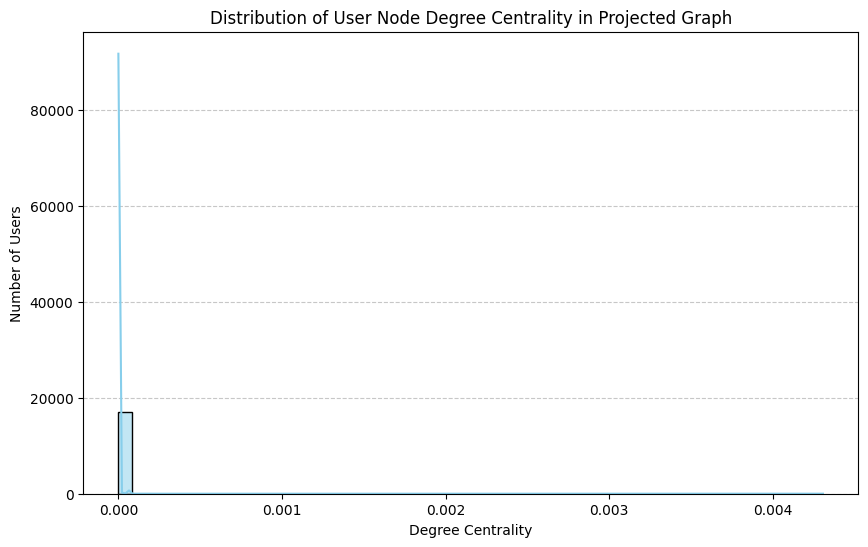

In [167]:
degree_centrality_users = nx.degree_centrality(G_user_projection)
user_centrality_series_projection = pd.Series(degree_centrality_users)

print("Descriptive statistics for User Node Centrality in Projected Graph:")
display(user_centrality_series_projection.describe())

plt.figure(figsize=(10, 6))
sns.histplot(user_centrality_series_projection, bins=50, kde=True, color='skyblue')
plt.title('Distribution of User Node Degree Centrality in Projected Graph')
plt.xlabel('Degree Centrality')
plt.ylabel('Number of Users')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

The mean was only 0.000001. The users in our projected graph were not very connected to each other. The stories they liked were very different.

We can also check story projection to see if we experience the same situation.

In [168]:
story_nodes_G_edge_sampled = [n for n, data in G_edge_sampled.nodes(data=True) if data.get('type') == 2]

print(f'Number of story nodes identified in G_edge_sampled: {len(story_nodes_G_edge_sampled)}')

G_story_projection = bipartite.projected_graph(G_edge_sampled, story_nodes_G_edge_sampled)

print(f'Number of nodes in G_story_projection: {G_story_projection.number_of_nodes()}')
print(f'Number of edges in G_story_projection: {G_story_projection.number_of_edges()}')

Number of story nodes identified in G_edge_sampled: 3482
Number of nodes in G_story_projection: 3482
Number of edges in G_story_projection: 141


Now, let's analyze the degree centrality of the story nodes in the projected graph to understand how interconnected stories are through shared users.

Descriptive statistics for Story Node Centrality in Projected Graph:


,0
count,3482.000000
mean,0.000023
std,0.000262
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,0.009193


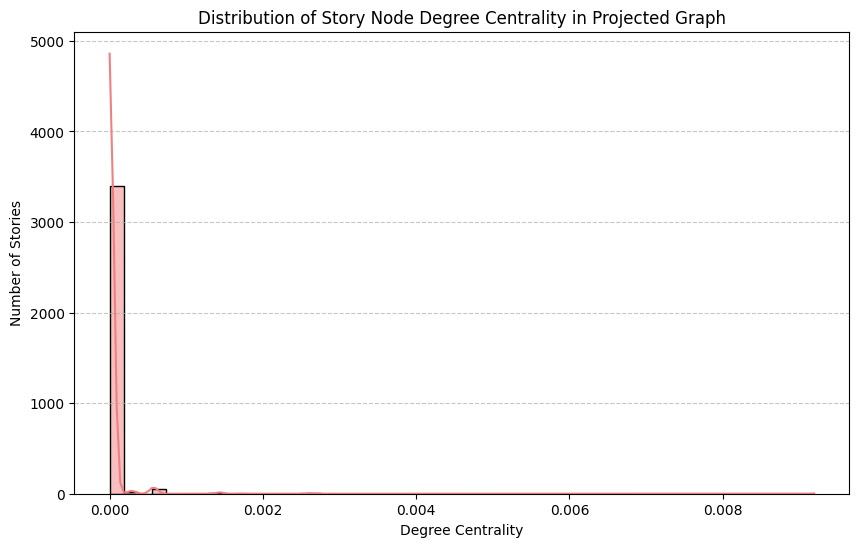

In [169]:
degree_centrality_stories = nx.degree_centrality(G_story_projection)
story_centrality_series_projection = pd.Series(degree_centrality_stories)

print("Descriptive statistics for Story Node Centrality in Projected Graph:")
display(story_centrality_series_projection.describe())

plt.figure(figsize=(10, 6))
sns.histplot(story_centrality_series_projection, bins=50, kde=True, color='lightcoral')
plt.title('Distribution of Story Node Degree Centrality in Projected Graph')
plt.xlabel('Degree Centrality')
plt.ylabel('Number of Stories')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

We get the similar results here. What is going on? We can compare these results to the earlier iterations of the dataset to get a better idea.

In [171]:
eigenvector_centrality_G_edge_sampled = nx.eigenvector_centrality(G_edge_sampled, max_iter=1000, tol=1e-06)

user_eigen_centrality_G_edge_sampled = {}
story_eigen_centrality_G_edge_sampled = {}

for node, centrality in eigenvector_centrality_G_edge_sampled.items():
    # Ensure the node exists in node_types_dict before accessing its type
    if node in node_types_dict:
        node_type = node_types_dict[node]
        if node_type == 1:
            user_eigen_centrality_G_edge_sampled[node] = centrality
        elif node_type == 2:
            story_eigen_centrality_G_edge_sampled[node] = centrality

user_eigen_centrality_series_G_edge_sampled = pd.Series(user_eigen_centrality_G_edge_sampled)
story_eigen_centrality_series_G_edge_sampled = pd.Series(story_eigen_centrality_G_edge_sampled)

print('Descriptive statistics for User Node Eigenvector Centrality in G_edge_sampled:')
display(user_eigen_centrality_series_G_edge_sampled.describe())

print('\nDescriptive statistics for Story Node Eigenvector Centrality in G_edge_sampled:')
display(story_eigen_centrality_series_G_edge_sampled.describe())


Descriptive statistics for User Node Eigenvector Centrality in G_edge_sampled:


,0
count,1.694800e+04
mean,3.516311e-04
std,7.671200e-03
min,2.674349e-07
25%,1.658096e-05
50%,1.658096e-05
75%,3.289449e-05
max,3.090927e-01



Descriptive statistics for Story Node Eigenvector Centrality in G_edge_sampled:


,0
count,3.482000e+03
mean,2.022129e-05
std,4.212238e-04
min,2.674349e-07
25%,2.674349e-07
50%,2.674349e-07
75%,2.674349e-07
max,1.567757e-02


Eigenvector centrality of the pre-projected graph are very low for both stories and users as values dip in to scientific notation. Unfortunately, verifying this against the original unreduced dataset would take an extremely long time to process. However, we did have degree centrality information where the highest user degree centrality was ~0.02 and the second highest story degree centrality was ~0.06. Recall that there was a lone story `280344` with a much higher degree centrality. The results reaffirm that besides the top stories, the connections between stories are very low.

### Conclusions

* There was little interconnectedness found for both user and story nodes.
* Clique analysis would not be useful with the low amount of interconnectedness found.
* There is a sampling error risk based on the sparseness.
* Regardless of sampling errors, `280344` must have been a very important story to overcome the overall sparseness of the connectiveness of the Digg network.